In [22]:
#import rebound
#import reboundx
import numpy as np
import matplotlib.pyplot as plt
import random
import astropy.units as u
import pandas as pd

In [23]:
MS_J=pd.read_csv('Jupiter_MS20a_3_40i.csv')
MS_S=pd.read_csv('Saturn_MS20a_3_40i.csv')
MS_U=pd.read_csv('Uranus_MS20a_3_40i.csv')
MS_N=pd.read_csv('Neptune_MS20a_3_40i.csv')
MS_MS=pd.read_csv('MS_MS20a_3_40i.csv')

In [24]:
WD_J=pd.read_csv('Jupiter_WD20a_3_40i.csv')
WD_S=pd.read_csv('Saturn_WD20a_3_40i.csv')
WD_U=pd.read_csv('Uranus_WD20a_3_40i.csv')
WD_N=pd.read_csv('Neptune_WD20a_3_40i.csv')
WD_MS=pd.read_csv('MS_WD20a_3_40i.csv')

In [25]:
xJ=MS_J['x(AU)'].values
yJ=MS_J['y(AU)'].values
zJ=MS_J['z(AU)'].values
vxJ=MS_J['vx(AU)'].values
vyJ=MS_J['vy(AU)'].values
vzJ=MS_J['vz(AU)'].values

xS=MS_S['x(AU)'].values
yS=MS_S['y(AU)'].values
zS=MS_S['z(AU)'].values
vxS=MS_S['vx(AU)'].values
vyS=MS_S['vy(AU)'].values
vzS=MS_S['vz(AU)'].values

xU=MS_U['x(AU)'].values
yU=MS_U['y(AU)'].values
zU=MS_U['z(AU)'].values
vxU=MS_U['vx(AU)'].values
vyU=MS_U['vy(AU)'].values
vzU=MS_U['vz(AU)'].values

xN=MS_N['x(AU)'].values
yN=MS_N['y(AU)'].values
zN=MS_N['z(AU)'].values
vxN=MS_N['vx(AU)'].values
vyN=MS_N['vy(AU)'].values
vzN=MS_N['vz(AU)'].values

xMS=MS_MS['x(AU)'].values
yMS=MS_MS['y(AU)'].values
zMS=MS_MS['z(AU)'].values
vxMS=MS_MS['vx(AU)'].values
vyMS=MS_MS['vy(AU)'].values
vzMS=MS_MS['vz(AU)'].values

In [26]:
xJw=WD_J['x(AU)'].values
yJw=WD_J['y(AU)'].values
zJw=WD_J['z(AU)'].values
vxJw=WD_J['vx(AU)'].values
vyJw=WD_J['vy(AU)'].values
vzJw=WD_J['vz(AU)'].values

xSw=WD_S['x(AU)'].values
ySw=WD_S['y(AU)'].values
zSw=WD_S['z(AU)'].values
vxSw=WD_S['vx(AU)'].values
vySw=WD_S['vy(AU)'].values
vzSw=WD_S['vz(AU)'].values

xUw=WD_U['x(AU)'].values
yUw=WD_U['y(AU)'].values
zUw=WD_U['z(AU)'].values
vxUw=WD_U['vx(AU)'].values
vyUw=WD_U['vy(AU)'].values
vzUw=WD_U['vz(AU)'].values

xNw=WD_N['x(AU)'].values
yNw=WD_N['y(AU)'].values
zNw=WD_N['z(AU)'].values
vxNw=WD_N['vx(AU)'].values
vyNw=WD_N['vy(AU)'].values
vzNw=WD_N['vz(AU)'].values

xMSw=WD_MS['x(AU)'].values
yMSw=WD_MS['y(AU)'].values
zMSw=WD_MS['z(AU)'].values
vxMSw=WD_MS['vx(AU)'].values
vyMSw=WD_MS['vy(AU)'].values
vzMSw=WD_MS['vz(AU)'].values

In [27]:
t=MS_J['t(yr)'].values
tJ=WD_J['t(yr)'].values+MS_J['t(yr)'].values[-1]
tS=WD_S['t(yr)'].values+MS_J['t(yr)'].values[-1]
tU=WD_U['t(yr)'].values+MS_J['t(yr)'].values[-1]
tN=WD_N['t(yr)'].values+MS_J['t(yr)'].values[-1]
tMS=WD_MS['t(yr)'].values+MS_J['t(yr)'].values[-1]

In [28]:
def current_a_e(x,y,z,vx,vy,vz,m):
    G=4*(np.pi**2)
    rvec=np.array([x,y,z])
    vvec=np.array([vx,vy,vz])
    v=np.sqrt((vx**2)+(vy**2)+(vz**2))
    r=np.sqrt((x**2)+(y**2)+(z**2))
    hx=y*vz-z*vy
    hy=z*vx-x*vz
    hz=x*vy-y*vx
    ex=(1/(m*G))*(vy*hz-vz*hy)-x/r
    ey=(1/(m*G))*(vz*hx-vx*hz)-y/r
    ez=(1/(m*G))*(vx*hy-vy*hx)-z/r
 
    e=np.sqrt(ex**2+ey**2+ez**2)

    a=((2/r)-(v**2/(G*m)))**-1

    n=np.array([-hy,hx,0])
    evec=np.array([ex,ey,ez])
    hvec=np.array([hx,hy,hz])
    
    if ez<0:
        om=2*np.pi-np.arccos(n@evec/np.sqrt(sum(n**2)*sum(evec**2)))
    else:
        om=np.arccos(n@evec/np.sqrt(sum(n**2)*sum(evec**2)))

    if rvec@vvec<0:
        f=2*np.pi-np.arccos(rvec@evec/(r*e))
    else:
        f=np.arccos(rvec@evec/(r*e))

    if hx<0:
        Om=2*np.pi-np.arccos(-hy/np.sqrt(sum(n**2)))
    else:
        Om=np.arccos(-hy/np.sqrt(sum(n**2)))

    i=np.arccos(hz/np.sqrt(sum(hvec**2)))

    return a,e,om,f,i,Om
        

In [29]:
J_MS=[]
S_MS=[]
U_MS=[]
N_MS=[]
M_MS=[]
for i in range(len(xJ)):
    aJ,eJ,omJ,fJ,iJ,OmJ=current_a_e(xJ[i],yJ[i],zJ[i],vxJ[i],vyJ[i],vzJ[i],3.0)
    aS,eS,omS,fS,iS,OmS=current_a_e(xS[i],yS[i],zS[i],vxS[i],vyS[i],vzS[i],3.0)
    aU,eU,omU,fU,iU,OmU=current_a_e(xU[i],yU[i],zU[i],vxU[i],vyU[i],vzU[i],3.0)
    aN,eN,omN,fN,iN,OmN=current_a_e(xN[i],yN[i],zN[i],vxN[i],vyN[i],vzN[i],3.0)
    aMS,eMS,omMS,fMS,iMS,OmMS=current_a_e(xMS[i],yMS[i],zMS[i],vxMS[i],vyMS[i],vzMS[i],3.0+0.81)

    J_MS.append(np.array([aJ,eJ,omJ,fJ,iJ,OmJ]))
    S_MS.append(np.array([aS,eS,omS,fS,iS,OmS]))
    U_MS.append(np.array([aU,eU,omU,fU,iU,OmU]))
    N_MS.append(np.array([aN,eN,omN,fN,iN,OmN]))
    M_MS.append(np.array([aMS,eMS,omMS,fMS,iMS,OmMS]))

In [30]:
M_MS[0][0]/N_MS[0][0]

19.990452715594074

In [31]:
J_MS[-1][4]*180/np.pi,xJ[-1],yJ[-1],zJ[-1]

(55.631573709199444, 0.5740567094903318, 4.039549803743768, 2.868481467630789)

In [32]:
J_WD=[]
S_WD=[]
U_WD=[]
N_WD=[]
M_WD=[]
for i in range(len(tJ)):
    aJ,eJ,omJ,fJ,iJ,OmJ=current_a_e(xJw[i],yJw[i],zJw[i],vxJw[i],vyJw[i],vzJw[i],0.7)
    J_WD.append(np.array([aJ,eJ,omJ,fJ,iJ,OmJ]))
for i in range(len(tS)):
    aS,eS,omS,fS,iS,OmS=current_a_e(xSw[i],ySw[i],zSw[i],vxSw[i],vySw[i],vzSw[i],0.7) 
    S_WD.append(np.array([aS,eS,omS,fS,iS,OmS]))
for i in range(len(tU)):
    aU,eU,omU,fU,iU,OmU=current_a_e(xUw[i],yUw[i],zUw[i],vxUw[i],vyUw[i],vzUw[i],0.7)
    U_WD.append(np.array([aU,eU,omU,fU,iU,OmU]))
for i in range(len(tN)):   
    aN,eN,omN,fN,iN,OmN=current_a_e(xNw[i],yNw[i],zNw[i],vxNw[i],vyNw[i],vzNw[i],0.7)
    N_WD.append(np.array([aN,eN,omN,fN,iN,OmN]))
for i in range(len(tMS)):    
    aMS,eMS,omMS,fMS,iMS,OmMS=current_a_e(xMSw[i],yMSw[i],zMSw[i],vxMSw[i],vyMSw[i],vzMSw[i],0.7+0.81)
    M_WD.append(np.array([aMS,eMS,omMS,fMS,iMS,OmMS]))

In [33]:
J_WD[0][4]*180/np.pi

56.149547377684705

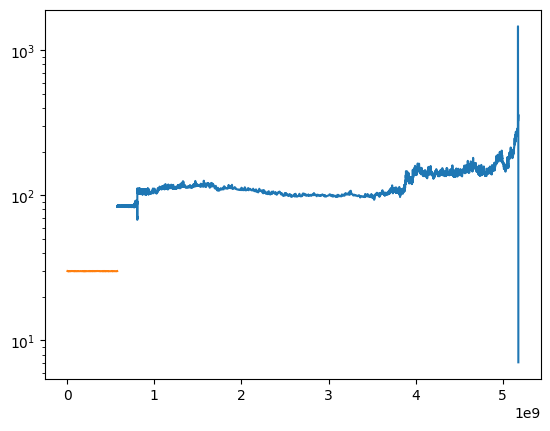

In [34]:
plt.semilogy(tN,np.array(N_WD)[:,0])
plt.semilogy(t,np.array(N_MS)[:,0])

In [35]:
def ticks_figure(ax):
    ax.xaxis.set_tick_params(width=1,length=8)
    ax.yaxis.set_tick_params(width=1,length=8)
    ax.xaxis.set_tick_params(which='minor',width=1,length=4)
    ax.yaxis.set_tick_params(which='minor',width=1,length=4)
    ax.xaxis.set_tick_params(tickdir="in", left="True",labelleft="True",right="True",labelsize=15)
    ax.yaxis.set_tick_params(tickdir="in", left="True",labelleft="True",right="True",labelsize=15)
    ax.xaxis.set_tick_params(tickdir="in", left="True",which='minor',labelleft="True",right="True",labelsize=15)
    ax.yaxis.set_tick_params(tickdir="in", left="True",which='minor',labelleft="True",right="True",labelsize=15)
    ax.minorticks_on()
    return

In [36]:
#plt.style.use('./apj.mplstyle')

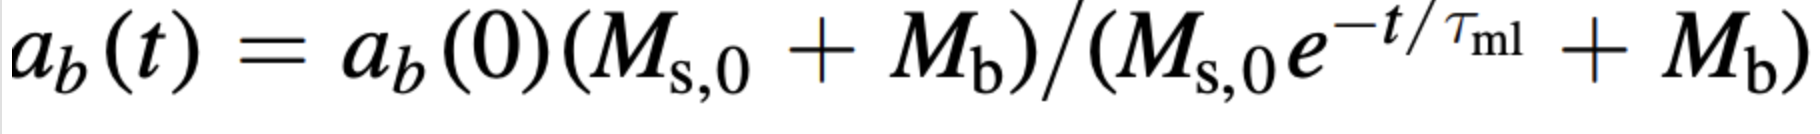

In [37]:
MSte=np.linspace(t[-1],tMS[0],10)

In [38]:
abt=np.array(M_MS)[:,0][-1]*(3+0.81)/(3*np.exp((MSte-t[-1])/(t[-1]-tMS[0]))+0.81)

Text(0, 0.5, '$a$ (AU)')

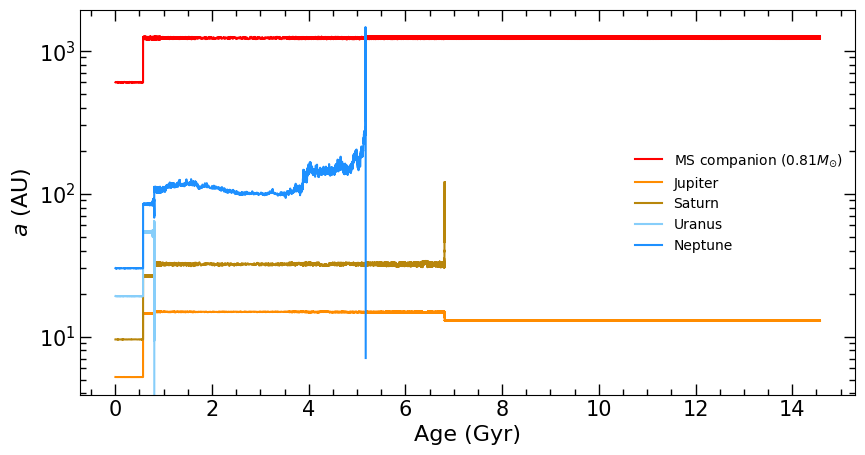

In [170]:
ff,ax=plt.subplots(1,1,figsize=(10,5))
#plt.rcParams.update({'text.usetex': False})
ticks_figure(ax)
plt.semilogy(np.concatenate([t,MSte,tMS])/1e9,(np.concatenate([np.array(M_MS)[:,0],abt,np.array(M_WD)[:,0]])),'-',color='red',label='MS companion ($0.81 M_{\odot}$)')
plt.semilogy(np.concatenate([t,tJ])/1e9,(np.concatenate([np.array(J_MS)[:,0],np.array(J_WD)[:,0]])),'-',color='darkorange',label='Jupiter')
plt.semilogy(np.concatenate([t,tS])/1e9,(np.concatenate([np.array(S_MS)[:,0],np.array(S_WD)[:,0]])),'-',color='darkgoldenrod',label='Saturn')
plt.semilogy(np.concatenate([t,tU])/1e9,(np.concatenate([np.array(U_MS)[:,0],np.array(U_WD)[:,0]])),'-',color='lightskyblue',label='Uranus')
plt.semilogy(np.concatenate([t,tN])/1e9,(np.concatenate([np.array(N_MS)[:,0],np.array(N_WD)[:,0]])),'-',color='dodgerblue',label='Neptune')
plt.legend(frameon=False)
plt.xlabel('Age (Gyr)',fontsize=16)
plt.ylabel(r'$a$ (AU)',fontsize=16)

(0.0, 7.0)

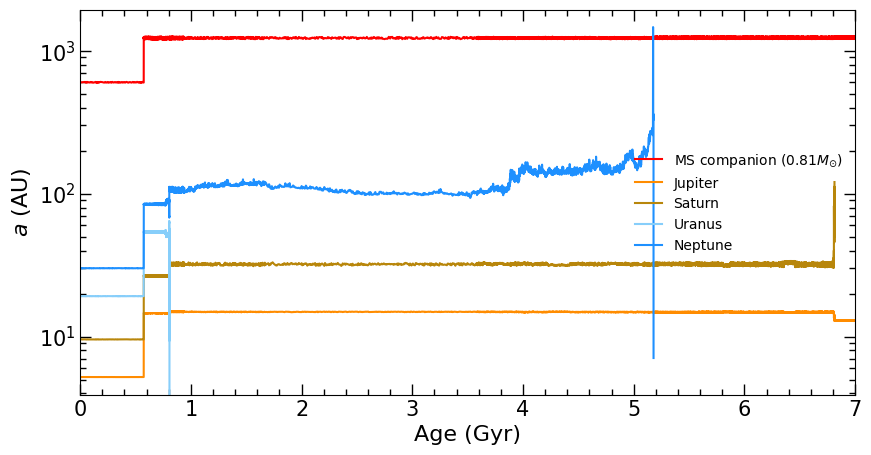

In [169]:
ff,ax=plt.subplots(1,1,figsize=(10,5))
#plt.rcParams.update({'text.usetex': False})
ticks_figure(ax)
plt.semilogy(np.concatenate([t,MSte,tMS])/1e9,(np.concatenate([np.array(M_MS)[:,0],abt,np.array(M_WD)[:,0]])),'-',color='red',label='MS companion ($0.81 M_{\odot}$)')
plt.semilogy(np.concatenate([t,tJ])/1e9,(np.concatenate([np.array(J_MS)[:,0],np.array(J_WD)[:,0]])),'-',color='darkorange',label='Jupiter')
plt.semilogy(np.concatenate([t,tS])/1e9,(np.concatenate([np.array(S_MS)[:,0],np.array(S_WD)[:,0]])),'-',color='darkgoldenrod',label='Saturn')
plt.semilogy(np.concatenate([t,tU])/1e9,(np.concatenate([np.array(U_MS)[:,0],np.array(U_WD)[:,0]])),'-',color='lightskyblue',label='Uranus')
plt.semilogy(np.concatenate([t,tN])/1e9,(np.concatenate([np.array(N_MS)[:,0],np.array(N_WD)[:,0]])),'-',color='dodgerblue',label='Neptune')
plt.legend(frameon=False)
plt.xlabel('Age (Gyr)',fontsize=16)
plt.ylabel(r'$a$ (AU)',fontsize=16)
plt.xlim(0,7)

In [339]:
#np.concatenate([np.array(N_MS)[:,0],np.array(N_WD)[:,0]])

In [161]:
import astropy.units as u

In [162]:
mass_Mercury=u.kg.to(u.Msun,3.3010e23) 
mass_Venus=u.kg.to(u.Msun,4.8673e24)
mass_Earth=u.kg.to(u.Msun,5.9722e24)
mass_Mars=u.kg.to(u.Msun,6.4169e23)
mass_Jupiter=u.kg.to(u.Msun,1.8981e27)
mass_Saturn=u.kg.to(u.Msun,5.6832e26)
mass_Uranus=u.kg.to(u.Msun,8.6810e25)
mass_Neptune=u.kg.to(u.Msun,1.0241e26)
mass_WD=0.72

In [163]:
qN=mass_WD/mass_Neptune
qU=mass_WD/mass_Uranus
qS=mass_WD/mass_Saturn
qJ=mass_WD/mass_Jupiter


RlN=np.concatenate([np.array(N_MS)[:,0],np.array(N_WD)[:,0]])*0.49*(qN**(2/3))/(0.6*(qN**(2/3))+np.log(1+(qN**(1/3))))
RlU=np.concatenate([np.array(U_MS)[:,0],np.array(U_WD)[:,0]])*0.49*(qU**(2/3))/(0.6*(qU**(2/3))+np.log(1+(qU**(1/3))))
RlS=np.concatenate([np.array(S_MS)[:,0],np.array(S_WD)[:,0]])*0.49*(qS**(2/3))/(0.6*(qS**(2/3))+np.log(1+(qS**(1/3))))
RlJ=np.concatenate([np.array(J_MS)[:,0],np.array(J_WD)[:,0]])*0.49*(qJ**(2/3))/(0.6*(qJ**(2/3))+np.log(1+(qJ**(1/3))))

Text(0, 0.5, '$a(1-e)$ (AU)')

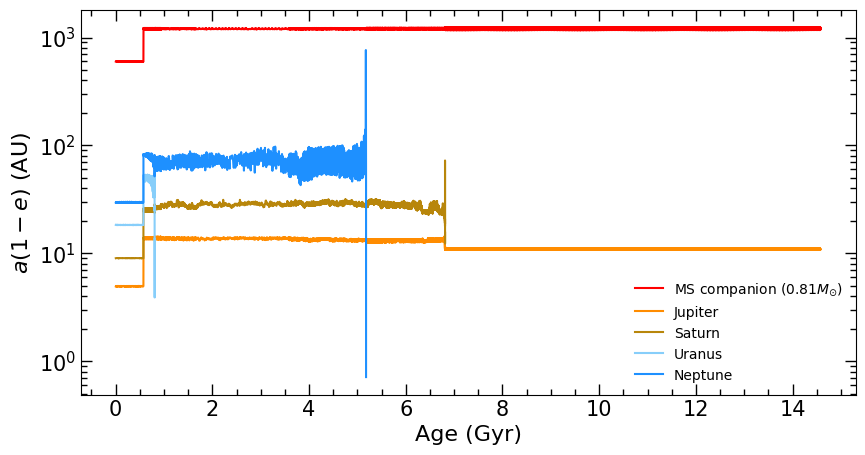

In [171]:
ff,ax=plt.subplots(1,1,figsize=(10,5))
ticks_figure(ax)
plt.semilogy(np.concatenate([t,tMS])/1e9,(1-np.concatenate([np.array(M_MS)[:,1],np.array(M_WD)[:,1]]))*np.concatenate([np.array(M_MS)[:,0],np.array(M_WD)[:,0]]),'-',color='red',label='MS companion ($0.81 M_{\odot}$)')
plt.semilogy(np.concatenate([t,tJ])/1e9,(1-np.concatenate([np.array(J_MS)[:,1],np.array(J_WD)[:,1]]))*np.concatenate([np.array(J_MS)[:,0],np.array(J_WD)[:,0]]),'-',color='darkorange',label='Jupiter')
plt.semilogy(np.concatenate([t,tS])/1e9,(1-np.concatenate([np.array(S_MS)[:,1],np.array(S_WD)[:,1]]))*np.concatenate([np.array(S_MS)[:,0],np.array(S_WD)[:,0]]),'-',color='darkgoldenrod',label='Saturn')
plt.semilogy(np.concatenate([t,tU])/1e9,(1-np.concatenate([np.array(U_MS)[:,1],np.array(U_WD)[:,1]]))*np.concatenate([np.array(U_MS)[:,0],np.array(U_WD)[:,0]]),'-',color='lightskyblue',label='Uranus')
plt.semilogy(np.concatenate([t,tN])/1e9,(1-np.concatenate([np.array(N_MS)[:,1],np.array(N_WD)[:,1]]))*np.concatenate([np.array(N_MS)[:,0],np.array(N_WD)[:,0]]),'-',color='dodgerblue',label='Neptune')

#plt.semilogy(np.concatenate([t,tMS])/1e9,,'--',color='red')
#plt.semilogy(np.concatenate([t,tJ])/1e9,RlJ,'--',color='darkorange')
#plt.semilogy(np.concatenate([t,tS])/1e9,RlS,'--',color='darkgoldenrod')
#plt.semilogy(np.concatenate([t,tU])/1e9,RlU,'--',color='lightskyblue')
#plt.semilogy(np.concatenate([t,tN])/1e9,RlN,'--',color='dodgerblue')

plt.legend(frameon=False)
plt.xlabel('Age (Gyr)',fontsize=16)
plt.ylabel(r'$a(1-e)$ (AU)',fontsize=16)
#plt.xlim(0,7)

(0.0, 7.0)

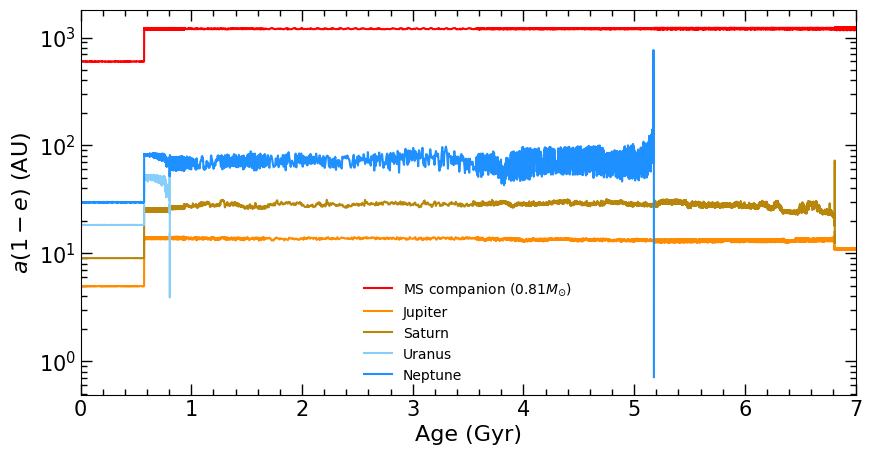

In [172]:
ff,ax=plt.subplots(1,1,figsize=(10,5))
ticks_figure(ax)
plt.semilogy(np.concatenate([t,tMS])/1e9,(1-np.concatenate([np.array(M_MS)[:,1],np.array(M_WD)[:,1]]))*np.concatenate([np.array(M_MS)[:,0],np.array(M_WD)[:,0]]),'-',color='red',label='MS companion ($0.81 M_{\odot}$)')
plt.semilogy(np.concatenate([t,tJ])/1e9,(1-np.concatenate([np.array(J_MS)[:,1],np.array(J_WD)[:,1]]))*np.concatenate([np.array(J_MS)[:,0],np.array(J_WD)[:,0]]),'-',color='darkorange',label='Jupiter')
plt.semilogy(np.concatenate([t,tS])/1e9,(1-np.concatenate([np.array(S_MS)[:,1],np.array(S_WD)[:,1]]))*np.concatenate([np.array(S_MS)[:,0],np.array(S_WD)[:,0]]),'-',color='darkgoldenrod',label='Saturn')
plt.semilogy(np.concatenate([t,tU])/1e9,(1-np.concatenate([np.array(U_MS)[:,1],np.array(U_WD)[:,1]]))*np.concatenate([np.array(U_MS)[:,0],np.array(U_WD)[:,0]]),'-',color='lightskyblue',label='Uranus')
plt.semilogy(np.concatenate([t,tN])/1e9,(1-np.concatenate([np.array(N_MS)[:,1],np.array(N_WD)[:,1]]))*np.concatenate([np.array(N_MS)[:,0],np.array(N_WD)[:,0]]),'-',color='dodgerblue',label='Neptune')
plt.legend(frameon=False)
plt.xlabel('Age (Gyr)',fontsize=16)
plt.ylabel(r'$a(1-e)$ (AU)',fontsize=16)
plt.xlim(0,7)

In [142]:
np.min((1-np.concatenate([np.array(N_MS)[:,1],np.array(N_WD)[:,1]]))*np.concatenate([np.array(N_MS)[:,0],np.array(N_WD)[:,0]]))

0.7119428440035858

Text(0, 0.5, '$e$')

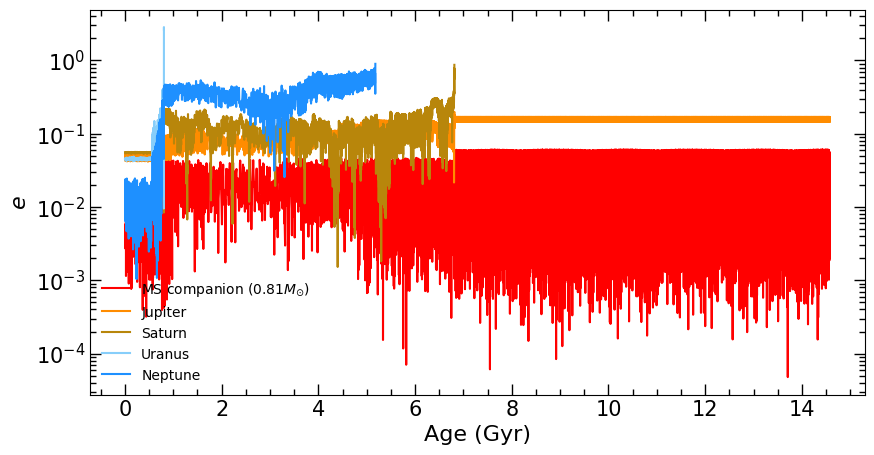

In [181]:
ff,ax=plt.subplots(1,1,figsize=(10,5))
#plt.rcParams.update({'text.usetex': False})
ticks_figure(ax)
plt.semilogy(np.concatenate([t,tMS])/1e9,(np.concatenate([np.array(M_MS)[:,1],np.array(M_WD)[:,1]])),'-',color='red',label='MS companion ($0.81 M_{\odot}$)')
plt.semilogy(np.concatenate([t,tJ])/1e9,(np.concatenate([np.array(J_MS)[:,1],np.array(J_WD)[:,1]])),'-',color='darkorange',label='Jupiter')
plt.semilogy(np.concatenate([t,tS])/1e9,(np.concatenate([np.array(S_MS)[:,1],np.array(S_WD)[:,1]])),'-',color='darkgoldenrod',label='Saturn')
plt.semilogy(np.concatenate([t,tU])/1e9,(np.concatenate([np.array(U_MS)[:,1],np.array(U_WD)[:,1]])),'-',color='lightskyblue',label='Uranus')
plt.semilogy(np.concatenate([t,tN])/1e9,(np.concatenate([np.array(N_MS)[:,1],np.array(N_WD)[:,1]])),'-',color='dodgerblue',label='Neptune')
plt.legend(frameon=False)
plt.xlabel('Age (Gyr)',fontsize=16)
plt.ylabel(r'$e$',fontsize=16)

(-0.05, 1.1)

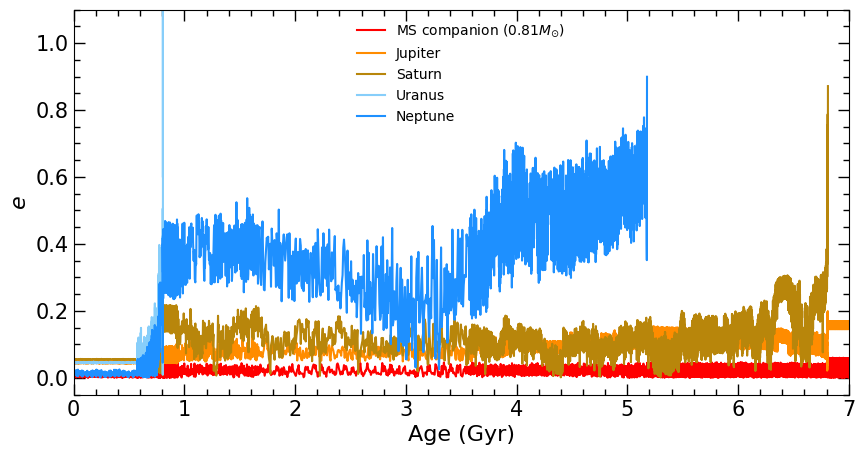

In [179]:
ff,ax=plt.subplots(1,1,figsize=(10,5))
#plt.rcParams.update({'text.usetex': False})
ticks_figure(ax)
plt.plot(np.concatenate([t,tMS])/1e9,(np.concatenate([np.array(M_MS)[:,1],np.array(M_WD)[:,1]])),'-',color='red',label='MS companion ($0.81 M_{\odot}$)')
plt.plot(np.concatenate([t,tJ])/1e9,(np.concatenate([np.array(J_MS)[:,1],np.array(J_WD)[:,1]])),'-',color='darkorange',label='Jupiter')
plt.plot(np.concatenate([t,tS])/1e9,(np.concatenate([np.array(S_MS)[:,1],np.array(S_WD)[:,1]])),'-',color='darkgoldenrod',label='Saturn')
plt.plot(np.concatenate([t,tU])/1e9,(np.concatenate([np.array(U_MS)[:,1],np.array(U_WD)[:,1]])),'-',color='lightskyblue',label='Uranus')
plt.plot(np.concatenate([t,tN])/1e9,(np.concatenate([np.array(N_MS)[:,1],np.array(N_WD)[:,1]])),'-',color='dodgerblue',label='Neptune')
plt.legend(frameon=False)
plt.xlabel('Age (Gyr)',fontsize=16)
plt.ylabel(r'$e$',fontsize=16)
plt.xlim(0,7)
plt.ylim(-0.05,1.1)

In [66]:
np.array(S_WD)[:,1]

array([0.0485649 , 0.04478336, 0.08582859, ..., 0.86423222, 0.85383806,
       0.871449  ])

Text(0, 0.5, '$i\\ (^{o})$')

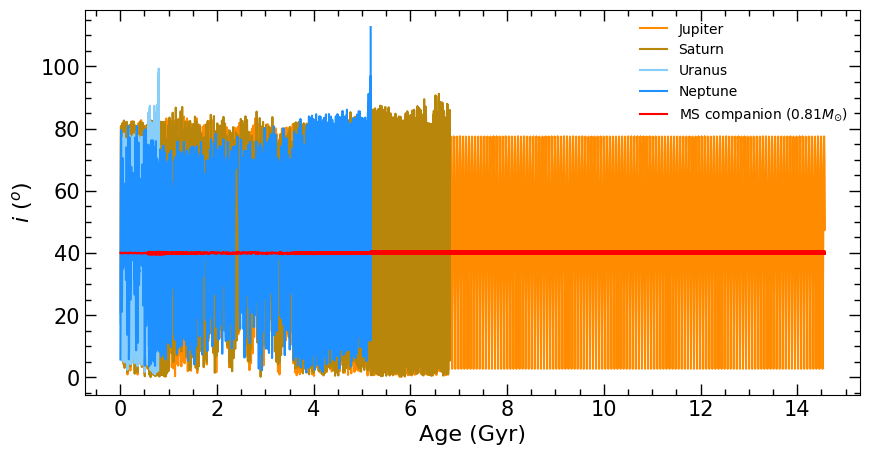

In [185]:
ff,ax=plt.subplots(1,1,figsize=(10,5))
#plt.rcParams.update({'text.usetex': False})
ticks_figure(ax)
#plt.plot(np.concatenate([t,tMS])/1e9,(np.concatenate([np.array(M_MS)[:,4],np.array(M_WD)[:,4]]))*180/np.pi,'-',color='red',label='MS companion ($0.81 M_{\odot}$)')
plt.plot(np.concatenate([t,tJ])/1e9,(np.concatenate([np.array(J_MS)[:,4],np.array(J_WD)[:,4]]))*180/np.pi,'-',color='darkorange',label='Jupiter')
plt.plot(np.concatenate([t,tS])/1e9,(np.concatenate([np.array(S_MS)[:,4],np.array(S_WD)[:,4]]))*180/np.pi,'-',color='darkgoldenrod',label='Saturn')
plt.plot(np.concatenate([t,tU])/1e9,(np.concatenate([np.array(U_MS)[:,4],np.array(U_WD)[:,4]]))*180/np.pi,'-',color='lightskyblue',label='Uranus')
plt.plot(np.concatenate([t,tN])/1e9,(np.concatenate([np.array(N_MS)[:,4],np.array(N_WD)[:,4]]))*180/np.pi,'-',color='dodgerblue',label='Neptune')
plt.plot(np.concatenate([t,tMS])/1e9,(np.concatenate([np.array(M_MS)[:,4],np.array(M_WD)[:,4]]))*180/np.pi,'-',color='red',label='MS companion ($0.81 M_{\odot}$)')

plt.legend(frameon=False)
plt.xlabel('Age (Gyr)',fontsize=16)
plt.ylabel(r'$i\ (^{o})$',fontsize=16)

(0.0, 7.0)

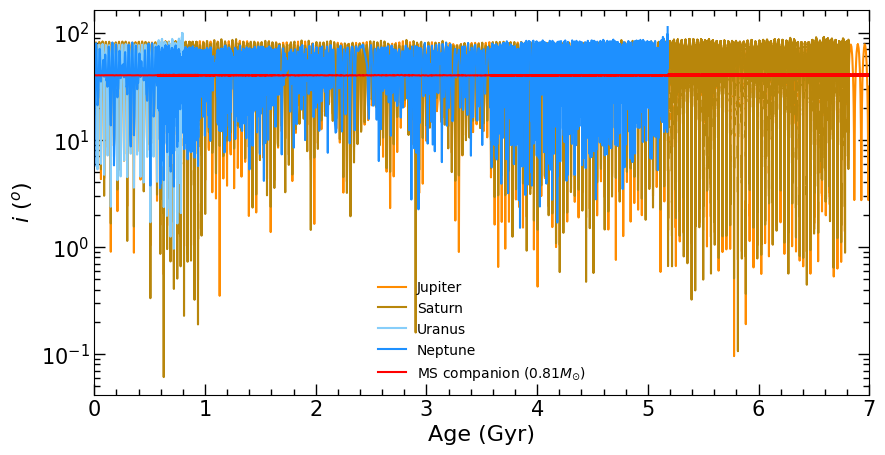

In [187]:
ff,ax=plt.subplots(1,1,figsize=(10,5))
#plt.rcParams.update({'text.usetex': False})
ticks_figure(ax)
#plt.plot(np.concatenate([t,tMS])/1e9,(np.concatenate([np.array(M_MS)[:,4],np.array(M_WD)[:,4]]))*180/np.pi,'-',color='red',label='MS companion ($0.81 M_{\odot}$)')
plt.semilogy(np.concatenate([t,tJ])/1e9,(np.concatenate([np.array(J_MS)[:,4],np.array(J_WD)[:,4]]))*180/np.pi,'-',color='darkorange',label='Jupiter')
plt.semilogy(np.concatenate([t,tS])/1e9,(np.concatenate([np.array(S_MS)[:,4],np.array(S_WD)[:,4]]))*180/np.pi,'-',color='darkgoldenrod',label='Saturn')
plt.semilogy(np.concatenate([t,tU])/1e9,(np.concatenate([np.array(U_MS)[:,4],np.array(U_WD)[:,4]]))*180/np.pi,'-',color='lightskyblue',label='Uranus')
plt.semilogy(np.concatenate([t,tN])/1e9,(np.concatenate([np.array(N_MS)[:,4],np.array(N_WD)[:,4]]))*180/np.pi,'-',color='dodgerblue',label='Neptune')
plt.semilogy(np.concatenate([t,tMS])/1e9,(np.concatenate([np.array(M_MS)[:,4],np.array(M_WD)[:,4]]))*180/np.pi,'-',color='red',label='MS companion ($0.81 M_{\odot}$)')

plt.legend(frameon=False)
plt.xlabel('Age (Gyr)',fontsize=16)
plt.ylabel(r'$i\ (^{o})$',fontsize=16)
plt.xlim(0,7)

In [120]:
def conic(a,e,om,f,i,Om):
    nu = np.linspace(0, 2*np.pi, 100)

    # Orbit in orbital plane
    if a>0:
        r = a * (1 - e**2) / (1 + e * np.cos(nu))

        x_orb = r * np.cos(nu)
        y_orb = r * np.sin(nu)
        z_orb = np.zeros_like(x_orb)
    elif a<0:
        H = np.linspace(-10, 10, 100)
        x_orb =- a * (e - np.cosh(H))
        y_orb =- a * np.sqrt(e**2 - 1) * np.sinh(H)
        z_orb = np.zeros_like(x_orb)

# Rotation matrices
    Rz_Omega = np.array([
    [np.cos(Om), -np.sin(Om), 0],
    [np.sin(Om),  np.cos(Om), 0],
    [0, 0, 1]
])

    Rx_i = np.array([
    [1, 0, 0],
    [0, np.cos(i), -np.sin(i)],
    [0, np.sin(i),  np.cos(i)]
])

    Rz_omega = np.array([
    [np.cos(om), -np.sin(om), 0],
    [np.sin(om),  np.cos(om), 0],
    [0, 0, 1]
])

    # Total rotation
    R = Rz_Omega @ Rx_i @ Rz_omega

    # Apply rotation
    coords = np.vstack((x_orb, y_orb, z_orb))
    x, y, z = R @ coords

    return np.array([x,y,z])

In [1]:
#J_MS

In [54]:
i=0

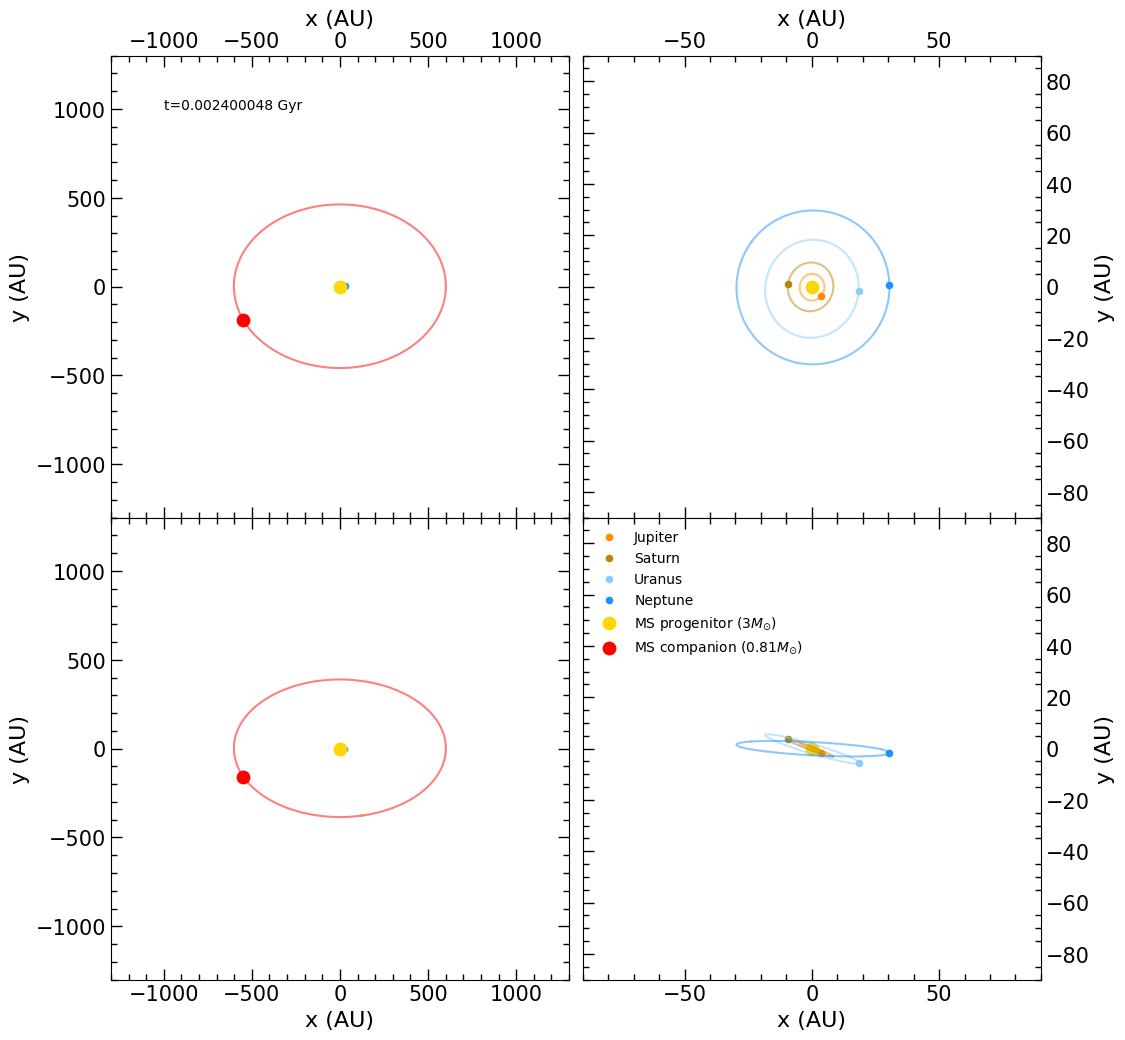

In [55]:
ff,ax=plt.subplots(2,2,figsize=(12,12))
plt.subplots_adjust(wspace=0.03, hspace=0.0)
ticks_figure(ax[0][0])
ticks_figure(ax[0][1])
ticks_figure(ax[1][1])
ticks_figure(ax[1][0])

ax[0][0].scatter(xJ[i],yJ[i],color='darkorange',s=20,label='Jupiter')
ax[0][0].scatter(xS[i],yS[i],color='darkgoldenrod',s=20,label='Saturn')
ax[0][0].scatter(xU[i],yU[i],color='lightskyblue',s=20,label='Uranus')
ax[0][0].scatter(xN[i],yN[i],color='dodgerblue',s=20,label='Neptune')
ax[0][0].scatter(0,0,color='gold',s=80,label='MS progenitor ($3 M_{\odot}$)')
#ax[0][0].scatter(0,0,color='orangered',s=180,label='MS progenitor ($3 M_{\odot}$)')
ax[0][0].scatter(xMS[i],yMS[i],color='red',s=80,label='MS companion ($0.81 M_{\odot}$)')

cM=conic(M_MS[i][0],M_MS[i][1],M_MS[i][2],M_MS[i][3],M_MS[i][4],M_MS[i][5])
ax[0][0].plot(cM[0],cM[1],color='red',alpha=0.5)

ax[0][0].set_xlim(-1300,1300)
ax[0][0].set_ylim(-1300,1300)

ax[0][1].scatter(xMS[i],yMS[i],color='red',s=80)
ax[0][1].scatter(xJ[i],yJ[i],color='darkorange',s=20)
ax[0][1].scatter(xS[i],yS[i],color='darkgoldenrod',s=20)
ax[0][1].scatter(xU[i],yU[i],color='lightskyblue',s=20)
ax[0][1].scatter(xN[i],yN[i],color='dodgerblue',s=20)
ax[0][1].scatter(0,0,color='gold',s=80)
#ax[0][1].scatter(0,0,color='orangered',s=180,label='MS progenitor ($3 M_{\odot}$)')


cJ=conic(J_MS[i][0],J_MS[i][1],J_MS[i][2],J_MS[i][3],J_MS[i][4],J_MS[i][5])
cS=conic(S_MS[i][0],S_MS[i][1],S_MS[i][2],S_MS[i][3],S_MS[i][4],S_MS[i][5])
cU=conic(U_MS[i][0],U_MS[i][1],U_MS[i][2],U_MS[i][3],U_MS[i][4],U_MS[i][5])
cN=conic(N_MS[i][0],N_MS[i][1],N_MS[i][2],N_MS[i][3],N_MS[i][4],N_MS[i][5])
ax[0][1].plot(cJ[0],cJ[1],color='darkorange',alpha=0.5)
ax[0][1].plot(cS[0],cS[1],color='darkgoldenrod',alpha=0.5)
ax[0][1].plot(cU[0],cU[1],color='lightskyblue',alpha=0.5)
ax[0][1].plot(cN[0],cN[1],color='dodgerblue',alpha=0.5)

ax[0][1].set_xlim(-90,90)
ax[0][1].set_ylim(-90,90)

ax[0][0].set_xlabel('x (AU)',fontsize=16)
ax[0][0].xaxis.set_label_position('top')
ax[0][0].set_ylabel('y (AU)',fontsize=16)
ax[0][1].set_xlabel('x (AU)',fontsize=16)
ax[0][1].xaxis.set_label_position('top')
ax[0][1].set_ylabel('y (AU)',fontsize=16)
ax[0][1].yaxis.set_label_position('right')

ax[0][0].tick_params(axis='x', top=True, labeltop=True,
               bottom=True, labelbottom=False)
ax[0][1].tick_params(axis='x', top=True, labeltop=True,
               bottom=True, labelbottom=False)

ax[1][0].scatter(xMS[i],zMS[i],color='red',s=80)
ax[1][0].scatter(xJ[i],zJ[i],color='darkorange',s=10)
ax[1][0].scatter(xS[i],zS[i],color='darkgoldenrod',s=10)
ax[1][0].scatter(xU[i],zU[i],color='lightskyblue',s=10)
ax[1][0].scatter(xN[i],zN[i],color='dodgerblue',s=10)
ax[1][0].scatter(0,0,color='gold',s=80)
#ax[1][0].scatter(0,0,color='orangered',s=180,label='MS progenitor ($3 M_{\odot}$)')
ax[1][0].plot(cM[0],cM[2],color='red',alpha=0.5)
ax[1][0].set_xlim(-1300,1300)
ax[1][0].set_ylim(-1300,1300)



ax[1][1].scatter(xJ[i],zJ[i],color='darkorange',s=20,label='Jupiter')
ax[1][1].scatter(xS[i],zS[i],color='darkgoldenrod',s=20,label='Saturn')
ax[1][1].scatter(xU[i],zU[i],color='lightskyblue',s=20,label='Uranus')
ax[1][1].scatter(xN[i],zN[i],color='dodgerblue',s=20,label='Neptune')
ax[1][1].scatter(0,0,color='gold',s=80,label='MS progenitor ($3 M_{\odot}$)')
#ax[1][1].scatter(0,0,color='orangered',s=180,label='MS progenitor ($3 M_{\odot}$)')
ax[1][1].scatter(xMS[i],zMS[i],color='red',s=80,label='MS companion ($0.81 M_{\odot}$)')
ax[1][1].plot(cJ[0],cJ[2],color='darkorange',alpha=0.5)
ax[1][1].plot(cS[0],cS[2],color='darkgoldenrod',alpha=0.5)
ax[1][1].plot(cU[0],cU[2],color='lightskyblue',alpha=0.5)
ax[1][1].plot(cN[0],cN[2],color='dodgerblue',alpha=0.5)

ax[1][1].set_xlim(-90,90)
ax[1][1].set_ylim(-90,90)

ax[1][1].tick_params(axis='y', right=False, labelright=True,
               left=True, labelleft=False)
ax[0][1].tick_params(axis='y', right=False, labelright=True,
               left=True, labelleft=False)

ax[1][0].set_xlabel('x (AU)',fontsize=16)
ax[1][0].set_ylabel('y (AU)',fontsize=16)
ax[1][1].set_xlabel('x (AU)',fontsize=16)
ax[1][1].set_ylabel('y (AU)',fontsize=16)
ax[1][1].yaxis.set_label_position('right')

ax[0][0].text(-1000,1000,'t='+str(t[i]/1e9)+' Gyr')
ax[1][1].legend(loc='upper left', frameon=False)


In [350]:
tJ

array([5.75209712e+08, 5.76809872e+08, 5.78410032e+08, 5.80010192e+08,
       5.81610352e+08, 5.83210512e+08, 5.84810672e+08, 5.86410832e+08,
       5.88010992e+08, 5.89611152e+08, 5.91211312e+08, 5.92811472e+08,
       5.94411632e+08, 5.96011792e+08, 5.97611952e+08, 5.99212112e+08,
       6.00812272e+08, 6.02412432e+08, 6.04012592e+08, 6.05612752e+08,
       6.07212912e+08, 6.08813072e+08, 6.10413232e+08, 6.12013392e+08,
       6.13613552e+08, 6.15213712e+08, 6.16813872e+08, 6.18414032e+08,
       6.20014192e+08, 6.21614352e+08, 6.23214512e+08, 6.24814672e+08,
       6.26414832e+08, 6.28014992e+08, 6.29615152e+08, 6.31215312e+08,
       6.32815472e+08, 6.34415632e+08, 6.36015792e+08, 6.37615952e+08,
       6.39216112e+08, 6.40816272e+08, 6.42416432e+08, 6.44016592e+08,
       6.45616752e+08, 6.47216912e+08, 6.48817072e+08, 6.50417232e+08,
       6.52017392e+08, 6.53617552e+08, 6.55217712e+08, 6.56817872e+08,
       6.58418032e+08, 6.60018192e+08, 6.61618352e+08, 6.63218512e+08,
      

In [68]:
i=-1#-1#91

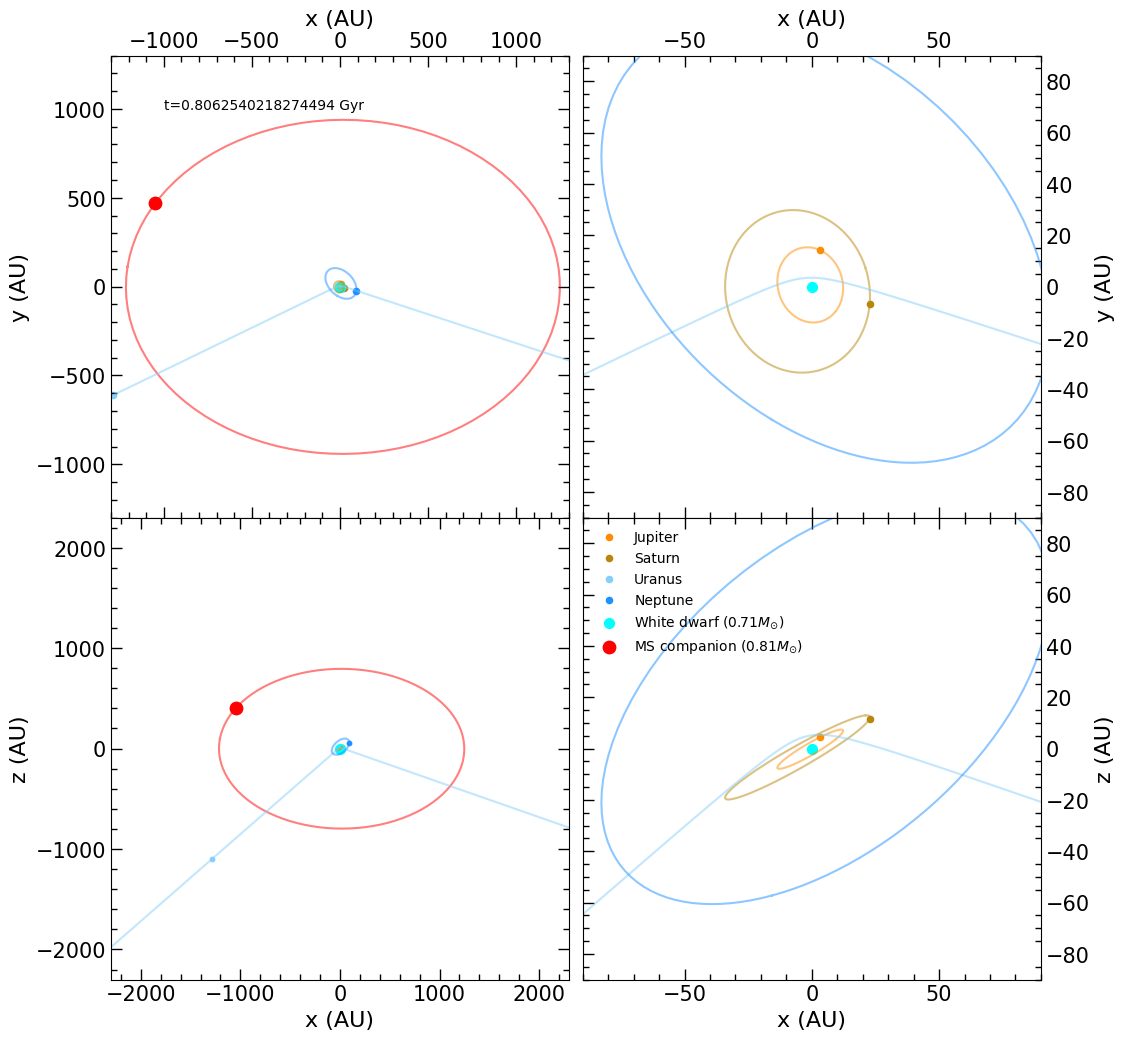

In [121]:
ff,ax=plt.subplots(2,2,figsize=(12,12))
plt.subplots_adjust(wspace=0.03, hspace=0.0)
ticks_figure(ax[0][0])
ticks_figure(ax[0][1])
ticks_figure(ax[1][1])
ticks_figure(ax[1][0])

ax[0][0].scatter(xJw[i],yJw[i],color='darkorange',s=20,label='Jupiter')
ax[0][0].scatter(xSw[i],ySw[i],color='darkgoldenrod',s=20,label='Saturn')
ax[0][0].scatter(xUw[i],yUw[i],color='lightskyblue',s=20,label='Uranus')
ax[0][0].scatter(xNw[i],yNw[i],color='dodgerblue',s=20,label='Neptune')
ax[0][0].scatter(0,0,color='cyan',s=50,label='White dwarf ($0.7 M_{\odot}$)')
ax[0][0].scatter(xMSw[i],yMSw[i],color='red',s=80,label='MS companion ($0.81 M_{\odot}$)')

cM=conic(M_WD[i][0],M_WD[i][1],M_WD[i][2],M_WD[i][3],M_WD[i][4],M_WD[i][5])
ax[0][0].plot(cM[0],cM[1],color='red',alpha=0.5)

ax[0][0].set_xlim(-1300,1300)
ax[0][0].set_ylim(-1300,1300)

ax[0][1].scatter(xMSw[i],yMSw[i],color='red',s=80)
ax[0][1].scatter(xJw[i],yJw[i],color='darkorange',s=20)
ax[0][1].scatter(xSw[i],ySw[i],color='darkgoldenrod',s=20)
ax[0][1].scatter(xUw[i],yUw[i],color='lightskyblue',s=20)
ax[0][1].scatter(xNw[i],yNw[i],color='dodgerblue',s=20)
ax[0][1].scatter(0,0,color='cyan',s=50)


cJ=conic(J_WD[i][0],J_WD[i][1],J_WD[i][2],J_WD[i][3],J_WD[i][4],J_WD[i][5])
cS=conic(S_WD[i][0],S_WD[i][1],S_WD[i][2],S_WD[i][3],S_WD[i][4],S_WD[i][5])
cU=conic(U_WD[i][0],U_WD[i][1],U_WD[i][2],U_WD[i][3],U_WD[i][4],U_WD[i][5])
cN=conic(N_WD[i][0],N_WD[i][1],N_WD[i][2],N_WD[i][3],N_WD[i][4],N_WD[i][5])

ax[0][0].plot(cJ[0],cJ[1],color='darkorange',alpha=0.5)
ax[0][0].plot(cS[0],cS[1],color='darkgoldenrod',alpha=0.5)
ax[0][0].plot(cU[0],cU[1],color='lightskyblue',alpha=0.5)
ax[0][0].plot(cN[0],cN[1],color='dodgerblue',alpha=0.5)
ax[0][1].plot(cJ[0],cJ[1],color='darkorange',alpha=0.5)
ax[0][1].plot(cS[0],cS[1],color='darkgoldenrod',alpha=0.5)
ax[0][1].plot(cU[0],cU[1],color='lightskyblue',alpha=0.5)
ax[0][1].plot(cN[0],cN[1],color='dodgerblue',alpha=0.5)
ax[0][0].scatter(0,0,color='cyan',s=50)

ax[0][1].set_xlim(-90,90)
ax[0][1].set_ylim(-90,90)

ax[0][0].set_xlabel('x (AU)',fontsize=16)
ax[0][0].xaxis.set_label_position('top')
ax[0][0].set_ylabel('y (AU)',fontsize=16)
ax[0][1].set_xlabel('x (AU)',fontsize=16)
ax[0][1].xaxis.set_label_position('top')
ax[0][1].set_ylabel('y (AU)',fontsize=16)
ax[0][1].yaxis.set_label_position('right')

ax[0][0].tick_params(axis='x', top=True, labeltop=True,
               bottom=True, labelbottom=False)
ax[0][1].tick_params(axis='x', top=True, labeltop=True,
               bottom=True, labelbottom=False)

ax[1][0].scatter(xMSw[i],zMSw[i],color='red',s=80)
ax[1][0].scatter(xJw[i],zJw[i],color='darkorange',s=10)
ax[1][0].scatter(xSw[i],zSw[i],color='darkgoldenrod',s=10)
ax[1][0].scatter(xUw[i],zUw[i],color='lightskyblue',s=10)
ax[1][0].scatter(xNw[i],zNw[i],color='dodgerblue',s=10)
ax[1][0].scatter(0,0,color='cyan',s=50)
ax[1][0].plot(cM[0],cM[2],color='red',alpha=0.5)
ax[1][0].set_xlim(-2300,2300)
ax[1][0].set_ylim(-2300,2300)



ax[1][1].scatter(xJw[i],zJw[i],color='darkorange',s=20,label='Jupiter')
ax[1][1].scatter(xSw[i],zSw[i],color='darkgoldenrod',s=20,label='Saturn')
ax[1][1].scatter(xUw[i],zUw[i],color='lightskyblue',s=20,label='Uranus')
ax[1][1].scatter(xNw[i],zNw[i],color='dodgerblue',s=20,label='Neptune')
ax[1][1].scatter(0,0,color='cyan',s=50,label='White dwarf ($0.71 M_{\odot}$)')
ax[1][1].scatter(xMSw[i],zMSw[i],color='red',s=80,label='MS companion ($0.81 M_{\odot}$)')
ax[1][0].plot(cJ[0],cJ[2],color='darkorange',alpha=0.5)
ax[1][0].plot(cS[0],cS[2],color='darkgoldenrod',alpha=0.5)
ax[1][0].plot(cU[0],cU[2],color='lightskyblue',alpha=0.5)
ax[1][0].plot(cN[0],cN[2],color='dodgerblue',alpha=0.5)
ax[1][1].plot(cJ[0],cJ[2],color='darkorange',alpha=0.5)
ax[1][1].plot(cS[0],cS[2],color='darkgoldenrod',alpha=0.5)
ax[1][1].plot(cU[0],cU[2],color='lightskyblue',alpha=0.5)
ax[1][1].plot(cN[0],cN[2],color='dodgerblue',alpha=0.5)
#ax[1][0].scatter(0,0,color='cyan',s=50)

ax[1][1].set_xlim(-90,90)
ax[1][1].set_ylim(-90,90)

ax[1][1].tick_params(axis='y', right=False, labelright=True,
               left=True, labelleft=False)
ax[0][1].tick_params(axis='y', right=False, labelright=True,
               left=True, labelleft=False)

ax[1][0].set_xlabel('x (AU)',fontsize=16)
ax[1][0].set_ylabel('z (AU)',fontsize=16)
ax[1][1].set_xlabel('x (AU)',fontsize=16)
ax[1][1].set_ylabel('z (AU)',fontsize=16)
ax[1][1].yaxis.set_label_position('right')

ax[0][0].text(-1000,1000,'t='+str(tJ[i]/1e9)+' Gyr')
ax[1][1].legend(loc='upper left', frameon=False)


In [71]:
for i in range(0, len(t)):
        ff,ax=plt.subplots(2,2,figsize=(12,12))
        plt.subplots_adjust(wspace=0.03, hspace=0.0)
        ticks_figure(ax[0][0])
        ticks_figure(ax[0][1])
        ticks_figure(ax[1][1])
        ticks_figure(ax[1][0])

        ax[0][0].scatter(xJ[i],yJ[i],color='darkorange',s=20,label='Jupiter')
        ax[0][0].scatter(xS[i],yS[i],color='darkgoldenrod',s=20,label='Saturn')
        ax[0][0].scatter(xU[i],yU[i],color='lightskyblue',s=20,label='Uranus')
        ax[0][0].scatter(xN[i],yN[i],color='dodgerblue',s=20,label='Neptune')
        ax[0][0].scatter(0,0,color='gold',s=80,label='MS progenitor ($3 M_{\odot}$)')
        #ax[0][0].scatter(0,0,color='orangered',s=180,label='RG progenitor ($<3 M_{\odot}$)')

        ax[0][0].scatter(xMS[i],yMS[i],color='red',s=80,label='MS companion ($0.81 M_{\odot}$)')
    

        cM=conic(M_MS[i][0],M_MS[i][1],M_MS[i][2],M_MS[i][3],M_MS[i][4],M_MS[i][5])
        ax[0][0].plot(cM[0],cM[1],color='red',alpha=0.5)

        ax[0][0].set_xlim(-1300,1300)
        ax[0][0].set_ylim(-1300,1300)

        ax[0][1].scatter(xMS[i],yMS[i],color='red',s=80)
        ax[0][1].scatter(xJ[i],yJ[i],color='darkorange',s=20)
        ax[0][1].scatter(xS[i],yS[i],color='darkgoldenrod',s=20)
        ax[0][1].scatter(xU[i],yU[i],color='lightskyblue',s=20)
        ax[0][1].scatter(xN[i],yN[i],color='dodgerblue',s=20)
        ax[0][1].scatter(0,0,color='gold',s=80)
        #ax[0][1].scatter(0,0,color='orangered',s=180,label='RG progenitor ($<3 M_{\odot}$)')



        cJ=conic(J_MS[i][0],J_MS[i][1],J_MS[i][2],J_MS[i][3],J_MS[i][4],J_MS[i][5])
        cS=conic(S_MS[i][0],S_MS[i][1],S_MS[i][2],S_MS[i][3],S_MS[i][4],S_MS[i][5])
        cU=conic(U_MS[i][0],U_MS[i][1],U_MS[i][2],U_MS[i][3],U_MS[i][4],U_MS[i][5])
        cN=conic(N_MS[i][0],N_MS[i][1],N_MS[i][2],N_MS[i][3],N_MS[i][4],N_MS[i][5])
        ax[0][1].plot(cJ[0],cJ[1],color='darkorange',alpha=0.5)
        ax[0][1].plot(cS[0],cS[1],color='darkgoldenrod',alpha=0.5)
        ax[0][1].plot(cU[0],cU[1],color='lightskyblue',alpha=0.5)
        ax[0][1].plot(cN[0],cN[1],color='dodgerblue',alpha=0.5)

        ax[0][1].set_xlim(-90,90)
        ax[0][1].set_ylim(-90,90)

        ax[0][0].set_xlabel('x (AU)',fontsize=16)
        ax[0][0].xaxis.set_label_position('top')
        ax[0][0].set_ylabel('y (AU)',fontsize=16)
        ax[0][1].set_xlabel('x (AU)',fontsize=16)
        ax[0][1].xaxis.set_label_position('top')
        ax[0][1].set_ylabel('y (AU)',fontsize=16)
        ax[0][1].yaxis.set_label_position('right')

        ax[0][0].tick_params(axis='x', top=True, labeltop=True,
                       bottom=True, labelbottom=False)
        ax[0][1].tick_params(axis='x', top=True, labeltop=True,
                       bottom=True, labelbottom=False)

        ax[1][0].scatter(xMS[i],zMS[i],color='red',s=80)
        ax[1][0].scatter(xJ[i],zJ[i],color='darkorange',s=10)
        ax[1][0].scatter(xS[i],zS[i],color='darkgoldenrod',s=10)
        ax[1][0].scatter(xU[i],zU[i],color='lightskyblue',s=10)
        ax[1][0].scatter(xN[i],zN[i],color='dodgerblue',s=10)
        ax[1][0].scatter(0,0,color='gold',s=80)
        #ax[1][0].scatter(0,0,color='orangered',s=180,label='RG progenitor ($<3 M_{\odot}$)')
        ax[1][0].plot(cM[0],cM[2],color='red',alpha=0.5)
        ax[1][0].set_xlim(-1300,1300)
        ax[1][0].set_ylim(-1300,1300)



        ax[1][1].scatter(xJ[i],zJ[i],color='darkorange',s=20,label='Jupiter')
        ax[1][1].scatter(xS[i],zS[i],color='darkgoldenrod',s=20,label='Saturn')
        ax[1][1].scatter(xU[i],zU[i],color='lightskyblue',s=20,label='Uranus')
        ax[1][1].scatter(xN[i],zN[i],color='dodgerblue',s=20,label='Neptune')
        ax[1][1].scatter(0,0,color='gold',s=80,label='MS progenitor ($3 M_{\odot}$)')
       # ax[1][1].scatter(0,0,color='orangered',s=180,label='RG progenitor ($<3 M_{\odot}$)')
        ax[1][1].scatter(xMS[i],zMS[i],color='red',s=80,label='MS companion ($0.81 M_{\odot}$)')
    
        ax[1][1].plot(cJ[0],cJ[2],color='darkorange',alpha=0.5)
        ax[1][1].plot(cS[0],cS[2],color='darkgoldenrod',alpha=0.5)
        ax[1][1].plot(cU[0],cU[2],color='lightskyblue',alpha=0.5)
        ax[1][1].plot(cN[0],cN[2],color='dodgerblue',alpha=0.5)

        ax[1][1].set_xlim(-90,90)
        ax[1][1].set_ylim(-90,90)

        ax[1][1].tick_params(axis='y', right=False, labelright=True,
                       left=True, labelleft=False)
        ax[0][1].tick_params(axis='y', right=False, labelright=True,
                       left=True, labelleft=False)

        ax[1][0].set_xlabel('x (AU)',fontsize=16)
        ax[1][0].set_ylabel('z (AU)',fontsize=16)
        ax[1][1].set_xlabel('x (AU)',fontsize=16)
        ax[1][1].set_ylabel('z (AU)',fontsize=16)
        ax[1][1].yaxis.set_label_position('right')
        
        ax[0][0].text(-1000,1000,'t='+str(t[i]/1e9)+' Gyr')
        ax[1][1].legend(loc='upper left', frameon=False)

        plt.gca().set_aspect('equal', adjustable='box')
        plt.savefig('png_1/plot%03d.png' % (i,))
        #plt.savefig('plot%03d.png' % (i,))

        plt.close()

In [143]:
len(tU)/(14*7),14*7,11214-len(t),10976-10,len(tU)-98,11116-len(t),(11191-len(t),11194-len(t)),(len(tS)-len(tN))/120

(113.0, 98, 10976, 10966, 10976, 10878, (10953, 10956), 105.86666666666666)

In [154]:
(len(tJ)-len(tS))/1000

384.954

In [155]:
for i in range(len(tS),len(tJ),1000):
    ff,ax=plt.subplots(2,2,figsize=(12,12))
    plt.subplots_adjust(wspace=0.03, hspace=0.0)
    ticks_figure(ax[0][0])
    ticks_figure(ax[0][1])
    ticks_figure(ax[1][1])
    ticks_figure(ax[1][0])

    ax[0][0].scatter(xJw[i],yJw[i],color='darkorange',s=20,label='Jupiter')
   # ax[0][0].scatter(xSw[i],ySw[i],color='darkgoldenrod',s=20,label='Saturn')
    #ax[0][0].scatter(xUw[i],yUw[i],color='lightskyblue',s=20,label='Uranus')
    #ax[0][0].scatter(xNw[i],yNw[i],color='dodgerblue',s=20,label='Neptune')
    ax[0][0].scatter(0,0,color='cyan',s=50,label='White dwarf ($0.72 M_{\odot}$)')
    ax[0][0].scatter(xMSw[i],yMSw[i],color='red',s=80,label='MS companion ($0.81 M_{\odot}$)')

    cM=conic(M_WD[i][0],M_WD[i][1],M_WD[i][2],M_WD[i][3],M_WD[i][4],M_WD[i][5])
    ax[0][0].plot(cM[0],cM[1],color='red',alpha=0.5)

    ax[0][0].set_xlim(-1300,1300)
    ax[0][0].set_ylim(-1300,1300)

    ax[0][1].scatter(xMSw[i],yMSw[i],color='red',s=80)
    ax[0][1].scatter(xJw[i],yJw[i],color='darkorange',s=20)
   # ax[0][1].scatter(xSw[i],ySw[i],color='darkgoldenrod',s=20)
    #ax[0][1].scatter(xUw[i],yUw[i],color='lightskyblue',s=20)
    #ax[0][1].scatter(xNw[i],yNw[i],color='dodgerblue',s=20)
    ax[0][1].scatter(0,0,color='cyan',s=50)


    cJ=conic(J_WD[i][0],J_WD[i][1],J_WD[i][2],J_WD[i][3],J_WD[i][4],J_WD[i][5])
   # cS=conic(S_WD[i][0],S_WD[i][1],S_WD[i][2],S_WD[i][3],S_WD[i][4],S_WD[i][5])
   # cU=conic(U_WD[i][0],U_WD[i][1],U_WD[i][2],U_WD[i][3],U_WD[i][4],U_WD[i][5])
    #cN=conic(N_WD[i][0],N_WD[i][1],N_WD[i][2],N_WD[i][3],N_WD[i][4],N_WD[i][5])

    ax[0][0].plot(cJ[0],cJ[1],color='darkorange',alpha=0.5)
   # ax[0][0].plot(cS[0],cS[1],color='darkgoldenrod',alpha=0.5)
    #ax[0][0].plot(cU[0],cU[1],color='lightskyblue',alpha=0.5)
    #ax[0][0].plot(cN[0],cN[1],color='dodgerblue',alpha=0.5)
    
    ax[0][1].plot(cJ[0],cJ[1],color='darkorange',alpha=0.5)
    #ax[0][1].plot(cS[0],cS[1],color='darkgoldenrod',alpha=0.5)
    #ax[0][1].plot(cU[0],cU[1],color='lightskyblue',alpha=0.5)
    #ax[0][1].plot(cN[0],cN[1],color='dodgerblue',alpha=0.5)
    ax[0][0].scatter(0,0,color='cyan',s=50)

    ax[0][1].set_xlim(-90,90)
    ax[0][1].set_ylim(-90,90)

    ax[0][0].set_xlabel('x (AU)',fontsize=16)
    ax[0][0].xaxis.set_label_position('top')
    ax[0][0].set_ylabel('y (AU)',fontsize=16)
    ax[0][1].set_xlabel('x (AU)',fontsize=16)
    ax[0][1].xaxis.set_label_position('top')
    ax[0][1].set_ylabel('y (AU)',fontsize=16)
    ax[0][1].yaxis.set_label_position('right')

    ax[0][0].tick_params(axis='x', top=True, labeltop=True,
                   bottom=True, labelbottom=False)
    ax[0][1].tick_params(axis='x', top=True, labeltop=True,
                   bottom=True, labelbottom=False)

    ax[1][0].scatter(xMSw[i],zMSw[i],color='red',s=80)
    ax[1][0].scatter(xJw[i],zJw[i],color='darkorange',s=10)
    #ax[1][0].scatter(xSw[i],zSw[i],color='darkgoldenrod',s=10)
    #ax[1][0].scatter(xUw[i],zUw[i],color='lightskyblue',s=10)
    #ax[1][0].scatter(xNw[i],zNw[i],color='dodgerblue',s=10)
    ax[1][0].scatter(0,0,color='cyan',s=50)
    ax[1][0].plot(cM[0],cM[2],color='red',alpha=0.5)
    ax[1][0].set_xlim(-1300,1300)
    ax[1][0].set_ylim(-1300,1300)



    ax[1][1].scatter(xJw[i],zJw[i],color='darkorange',s=20,label='Jupiter')
    #ax[1][1].scatter(xSw[i],zSw[i],color='darkgoldenrod',s=20,label='Saturn')
    #ax[1][1].scatter(xUw[i],zUw[i],color='lightskyblue',s=20,label='Uranus')
    #ax[1][1].scatter(xNw[i],zNw[i],color='dodgerblue',s=20,label='Neptune')
    ax[1][1].scatter(0,0,color='cyan',s=50,label='White dwarf ($0.72 M_{\odot}$)')
    ax[1][1].scatter(xMSw[i],zMSw[i],color='red',s=80,label='MS companion ($0.81 M_{\odot}$)')
    ax[1][0].plot(cJ[0],cJ[2],color='darkorange',alpha=0.5)
    #ax[1][0].plot(cS[0],cS[2],color='darkgoldenrod',alpha=0.5)
   # ax[1][0].plot(cU[0],cU[2],color='lightskyblue',alpha=0.5)
   # ax[1][0].plot(cN[0],cN[2],color='dodgerblue',alpha=0.5)
    ax[1][1].plot(cJ[0],cJ[2],color='darkorange',alpha=0.5)
   # ax[1][1].plot(cS[0],cS[2],color='darkgoldenrod',alpha=0.5)
    #ax[1][1].plot(cU[0],cU[2],color='lightskyblue',alpha=0.5)
   # ax[1][1].plot(cN[0],cN[2],color='dodgerblue',alpha=0.5)
#ax[1][0].scatter(0,0,color='cyan',s=50)

    ax[1][1].set_xlim(-90,90)
    ax[1][1].set_ylim(-90,90)

    ax[1][1].tick_params(axis='y', right=False, labelright=True,
               left=True, labelleft=False)
    ax[0][1].tick_params(axis='y', right=False, labelright=True,
               left=True, labelleft=False)

    ax[1][0].set_xlabel('x (AU)',fontsize=16)
    ax[1][0].set_ylabel('z (AU)',fontsize=16)
    ax[1][1].set_xlabel('x (AU)',fontsize=16)
    ax[1][1].set_ylabel('z (AU)',fontsize=16)
    ax[1][1].yaxis.set_label_position('right')

    ax[0][0].text(-1000,1000,'t='+str(tJ[i]/1e9)+' Gyr')
    ax[1][1].legend(loc='upper left', frameon=False)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.savefig('png_1/plot%03d.png' % (i+len(t),))

    plt.close()